# Самописный MLP на CPU: Бинарная классификация на датасете Banknote Authentication

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Архитектура MLP

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


class MLP:
    """
    Многослойный перцептрон с возможностью настройки архитектуры.
    Поддерживает бинарную классификацию с сигмоидой на выходе.
    """

    def __init__(self, layer_sizes, activation='relu', learning_rate=0.01,
                 batch_size=32, epochs=100, l2_lambda=0.001, random_state=42):
        """
        layer_sizes: список размеров слоёв [входной, скрытый1, скрытый2, ..., выходной]
        activation: функция активации ('relu', 'tanh')
        learning_rate: скорость обучения
        batch_size: размер мини-батча
        epochs: количество эпох
        l2_lambda: коэффициент L2-регуляризации
        random_state: seed для воспроизводимости
        """
        np.random.seed(random_state)
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.l2_lambda = l2_lambda
        self.random_state = random_state

        # Инициализация весов и смещений (инициализация He для ReLU)
        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1):
            # Инициализация He для ReLU, Xavier для tanh
            if activation == 'relu':
                scale = np.sqrt(2.0 / layer_sizes[i])
            else:
                scale = np.sqrt(1.0 / layer_sizes[i])

            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)

        # Сохраняем историю ошибок для построения графиков
        self.train_loss_history = []
        self.val_loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []

    def _activation(self, x):
        if self.activation == 'relu':
            return np.maximum(0, x)
        elif self.activation == 'tanh':
            return np.tanh(x)
        else:
            return x  # linear (for output layer in regression)

    def _activation_derivative(self, x):
        if self.activation == 'relu':
            return (x > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(x) ** 2
        else:
            return np.ones_like(x)

    def _sigmoid(self, x):
        # Стабильная сигмоида
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def _sigmoid_derivative(self, x):
        s = self._sigmoid(x)
        return s * (1 - s)

    def forward(self, X):
        """Прямой проход"""
        self.cache = {'a0': X}
        a = X

        # Проходим по всем слоям, кроме последнего
        for i in range(len(self.weights) - 1):
            z = a @ self.weights[i] + self.biases[i]
            a = self._activation(z)
            self.cache[f'z{i+1}'] = z
            self.cache[f'a{i+1}'] = a

        # Последний слой — сигмоида (для бинарной классификации)
        z_out = a @ self.weights[-1] + self.biases[-1]
        a_out = self._sigmoid(z_out)
        self.cache['z_out'] = z_out
        self.cache['a_out'] = a_out
        self.cache['a_last'] = a  # сохраняем активацию предпоследнего слоя

        return a_out

    def backward(self, X, y, y_pred):
        """Обратный проход"""
        m = X.shape[0]
        gradients_w = []
        gradients_b = []

        # Градиент для выходного слоя (сигмоида + бинарная кросс-энтропия)
        # dL/dz = y_pred - y (для бинарной кросс-энтропии с сигмоидой)
        delta = y_pred - y  # размер: (batch_size, 1)

        # Получаем активацию предыдущего слоя
        a_prev = self.cache['a_last']

        # Градиенты для выходного слоя
        grad_w = (a_prev.T @ delta) / m + self.l2_lambda * self.weights[-1] / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        gradients_w.append(grad_w)
        gradients_b.append(grad_b)

        # Градиенты для скрытых слоёв (обратный проход)
        delta_next = delta

        # Проходим от предпоследнего слоя к первому
        for i in range(len(self.weights) - 2, -1, -1):
            w = self.weights[i + 1]
            z = self.cache[f'z{i+1}']

            # Градиент относительно активации предыдущего слоя
            da = delta_next @ w.T

            # Градиент относительно z (производная активации)
            dz = da * self._activation_derivative(z)

            # Получаем активацию предыдущего слоя
            a_prev = self.cache[f'a{i}'] if i > 0 else X

            # Градиенты для текущего слоя
            grad_w = (a_prev.T @ dz) / m + self.l2_lambda * self.weights[i] / m
            grad_b = np.sum(dz, axis=0, keepdims=True) / m

            gradients_w.append(grad_w)
            gradients_b.append(grad_b)

            delta_next = dz

        # Разворачиваем градиенты в правильном порядке (от первого слоя к последнему)
        gradients_w.reverse()
        gradients_b.reverse()

        return gradients_w, gradients_b

    def update_weights(self, gradients_w, gradients_b):
        """Обновление весов"""
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * gradients_w[i]
            self.biases[i] -= self.learning_rate * gradients_b[i]

    def fit(self, X_train, y_train, X_val=None, y_val=None, verbose=True):
        """Обучение модели"""
        n_samples = X_train.shape[0]

        # Преобразуем y в двумерный массив для удобства
        y_train = y_train.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)

        for epoch in range(self.epochs):
            # Перемешивание данных
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            epoch_loss = 0
            epoch_correct = 0

            # Мини-батчевый SGD
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                # Прямой проход
                y_pred = self.forward(X_batch)

                # Вычисление градиентов
                gradients_w, gradients_b = self.backward(X_batch, y_batch, y_pred)

                # Обновление весов
                self.update_weights(gradients_w, gradients_b)

                # Вычисление ошибки для батча
                batch_loss = self._binary_cross_entropy(y_batch, y_pred)
                epoch_loss += batch_loss * len(X_batch)

                # Точность батча
                batch_pred = (y_pred >= 0.5).astype(int)
                epoch_correct += np.sum(batch_pred == y_batch)

            # Средняя ошибка и точность за эпоху
            train_loss = epoch_loss / n_samples
            train_acc = epoch_correct / n_samples

            self.train_loss_history.append(train_loss)
            self.train_acc_history.append(train_acc)

            # Валидация
            if X_val is not None:
                val_pred = self.forward(X_val)
                val_loss = self._binary_cross_entropy(y_val, val_pred)
                val_acc = accuracy_score(y_val.flatten(), (val_pred >= 0.5).astype(int).flatten())
                self.val_loss_history.append(val_loss)
                self.val_acc_history.append(val_acc)

                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs} - "
                          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
            else:
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs} - "
                          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    def predict_proba(self, X):
        """Предсказание вероятностей"""
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        """Предсказание классов"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int).flatten()

    def _binary_cross_entropy(self, y_true, y_pred):
        """Бинарная кросс-энтропия"""
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## Загрузка и предобработка данных

In [10]:
# Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
data = pd.read_csv(url, header=None, names=columns)

print("Размер данных:", data.shape)
print("\nПервые 5 строк:")
data.head()

Размер данных: (1372, 5)

Первые 5 строк:


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [11]:
# Информация о данных
print("Информация о данных:")
data.info()
print("\nСтатистика:")
data.describe()

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Статистика:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


Распределение классов:
Class
0    762
1    610
Name: count, dtype: int64

Доля каждого класса:
Class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


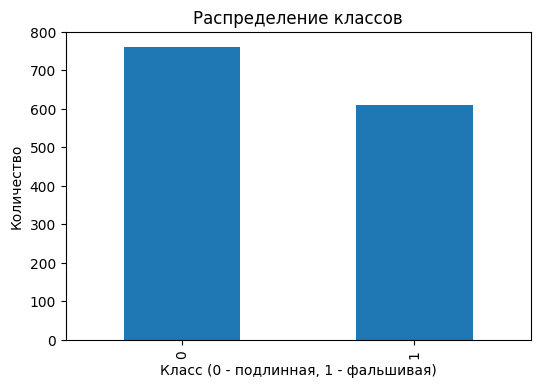

In [12]:
# Проверка баланса классов
print("Распределение классов:")
print(data['Class'].value_counts())
print("\nДоля каждого класса:")
print(data['Class'].value_counts(normalize=True))

# Визуализация распределения классов
plt.figure(figsize=(6, 4))
data['Class'].value_counts().plot(kind='bar')
plt.title('Распределение классов')
plt.xlabel('Класс (0 - подлинная, 1 - фальшивая)')
plt.ylabel('Количество')
plt.show()

In [13]:
# Разделение на признаки и целевую переменную
X = data.drop('Class', axis=1).values
y = data['Class'].values

# Разделение на train/val/test (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 823
Размер валидационной выборки: 274
Размер тестовой выборки: 275


In [14]:
# Масштабирование признаков (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Средние значения после масштабирования:")
print(X_train_scaled.mean(axis=0))
print("\nСтандартные отклонения после масштабирования:")
print(X_train_scaled.std(axis=0))

Средние значения после масштабирования:
[-8.61839289e-17 -1.30110584e-16 -2.45517121e-17  1.33550522e-16]

Стандартные отклонения после масштабирования:
[1. 1. 1. 1.]


## Обучение модели
### Подбор архитектуры и гиперпараметров

In [15]:
# Определение архитектур для экспериментов
architectures = [
    [4, 32, 1],
    [4, 64, 1],
    [4, 32, 16, 1],
    [4, 64, 32, 1],
]

# Гиперпараметры для экспериментов
learning_rates = [0.01, 0.005, 0.001]
batch_sizes = [16, 32, 64]
l2_lambdas = [0.0, 0.001, 0.01]

# Эксперименты
best_val_acc = 0
best_params = None
best_model = None
results = []

print("Начало подбора гиперпараметров...")

for arch in architectures:
    for lr in learning_rates:
        for bs in batch_sizes:
            for l2 in l2_lambdas:
                # Пропускаем некоторые комбинации для ускорения
                if len(arch) > 3 and bs < 32:
                    continue

                model = MLP(
                    layer_sizes=arch,
                    activation='relu',
                    learning_rate=lr,
                    batch_size=bs,
                    epochs=50,
                    l2_lambda=l2,
                    random_state=42
                )

                model.fit(X_train_scaled, y_train, X_val_scaled, y_val, verbose=False)

                val_pred = model.predict(X_val_scaled)
                val_acc = accuracy_score(y_val, val_pred)

                results.append({
                    'architecture': arch,
                    'learning_rate': lr,
                    'batch_size': bs,
                    'l2_lambda': l2,
                    'val_acc': val_acc
                })

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_params = (arch, lr, bs, l2)
                    best_model = model

                print(f"Arch: {arch}, LR: {lr}, BS: {bs}, L2: {l2} -> Val Acc: {val_acc:.4f}")

print(f"\nЛучшая валидационная точность: {best_val_acc:.4f}")
print(f"Лучшие параметры: Architecture={best_params[0]}, LR={best_params[1]}, "
      f"BS={best_params[2]}, L2={best_params[3]}")

Начало подбора гиперпараметров...
Arch: [4, 32, 1], LR: 0.01, BS: 16, L2: 0.0 -> Val Acc: 0.9781
Arch: [4, 32, 1], LR: 0.01, BS: 16, L2: 0.001 -> Val Acc: 0.9781
Arch: [4, 32, 1], LR: 0.01, BS: 16, L2: 0.01 -> Val Acc: 0.9781
Arch: [4, 32, 1], LR: 0.01, BS: 32, L2: 0.0 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.01, BS: 32, L2: 0.001 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.01, BS: 32, L2: 0.01 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.01, BS: 64, L2: 0.0 -> Val Acc: 0.9489
Arch: [4, 32, 1], LR: 0.01, BS: 64, L2: 0.001 -> Val Acc: 0.9489
Arch: [4, 32, 1], LR: 0.01, BS: 64, L2: 0.01 -> Val Acc: 0.9489
Arch: [4, 32, 1], LR: 0.005, BS: 16, L2: 0.0 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.005, BS: 16, L2: 0.001 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.005, BS: 16, L2: 0.01 -> Val Acc: 0.9745
Arch: [4, 32, 1], LR: 0.005, BS: 32, L2: 0.0 -> Val Acc: 0.9489
Arch: [4, 32, 1], LR: 0.005, BS: 32, L2: 0.001 -> Val Acc: 0.9489
Arch: [4, 32, 1], LR: 0.005, BS: 32, L2: 0.01 -> Val Acc: 0.9489


### Обучение лучшей модели с большим количеством эпох

In [16]:
# Создание и обучение лучшей модели с полным числом эпох
final_model = MLP(
    layer_sizes=best_params[0],
    activation='relu',
    learning_rate=best_params[1],
    batch_size=best_params[2],
    epochs=150,
    l2_lambda=best_params[3],
    random_state=42
)

final_model.fit(X_train_scaled, y_train, X_val_scaled, y_val, verbose=True)

Epoch 10/150 - Train Loss: 0.1391, Train Acc: 0.9623, Val Loss: 0.1341, Val Acc: 0.9672
Epoch 20/150 - Train Loss: 0.0888, Train Acc: 0.9769, Val Loss: 0.0830, Val Acc: 0.9745
Epoch 30/150 - Train Loss: 0.0682, Train Acc: 0.9793, Val Loss: 0.0626, Val Acc: 0.9781
Epoch 40/150 - Train Loss: 0.0566, Train Acc: 0.9806, Val Loss: 0.0516, Val Acc: 0.9781
Epoch 50/150 - Train Loss: 0.0488, Train Acc: 0.9854, Val Loss: 0.0446, Val Acc: 0.9891
Epoch 60/150 - Train Loss: 0.0433, Train Acc: 0.9854, Val Loss: 0.0396, Val Acc: 0.9891
Epoch 70/150 - Train Loss: 0.0389, Train Acc: 0.9927, Val Loss: 0.0356, Val Acc: 0.9891
Epoch 80/150 - Train Loss: 0.0354, Train Acc: 0.9939, Val Loss: 0.0324, Val Acc: 0.9891
Epoch 90/150 - Train Loss: 0.0325, Train Acc: 0.9939, Val Loss: 0.0298, Val Acc: 0.9891
Epoch 100/150 - Train Loss: 0.0300, Train Acc: 0.9939, Val Loss: 0.0275, Val Acc: 0.9891
Epoch 110/150 - Train Loss: 0.0279, Train Acc: 0.9939, Val Loss: 0.0255, Val Acc: 0.9891
Epoch 120/150 - Train Loss: 0.

## Оценка качества на тестовой выборке

In [17]:
# Получение предсказаний на тестовой выборке
y_test_pred = final_model.predict(X_test_scaled)
y_test_proba = final_model.predict_proba(X_test_scaled)

# Базовые метрики
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Метрики на тестовой выборке:
Accuracy:  0.9964
Precision: 0.9919
Recall:    1.0000
F1-score:  0.9959
ROC-AUC:   1.0000


## Подбор оптимального порога

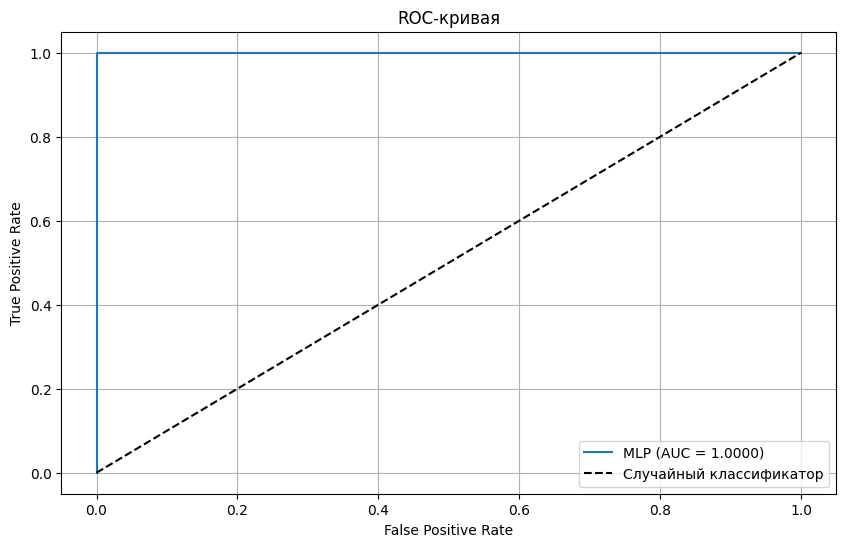

Оптимальный порог по критерию Юдена: 0.7532

Метрики при оптимальном пороге (0.7532):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

При пороге 0.5:
Accuracy:  0.9964
Precision: 0.9919
Recall:    1.0000
F1-score:  0.9959


In [18]:
# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

# Критерий Юдена для выбора оптимального порога
youden_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_idx]
print(f"Оптимальный порог по критерию Юдена: {optimal_threshold:.4f}")

# Метрики при оптимальном пороге
y_test_opt = (y_test_proba >= optimal_threshold).astype(int)
opt_accuracy = accuracy_score(y_test, y_test_opt)
opt_precision = precision_score(y_test, y_test_opt)
opt_recall = recall_score(y_test, y_test_opt)
opt_f1 = f1_score(y_test, y_test_opt)

print(f"\nМетрики при оптимальном пороге ({optimal_threshold:.4f}):")
print(f"Accuracy:  {opt_accuracy:.4f}")
print(f"Precision: {opt_precision:.4f}")
print(f"Recall:    {opt_recall:.4f}")
print(f"F1-score:  {opt_f1:.4f}")

# Сравнение с порогом 0.5
print(f"\nПри пороге 0.5:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

## Зависимость метрик от порога

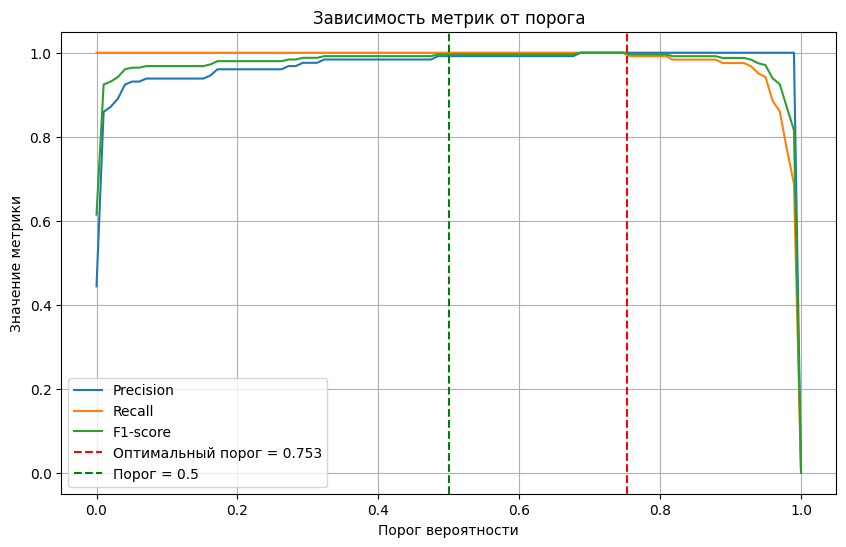

In [19]:
# Вычисление метрик для различных порогов
thresholds_range = np.linspace(0, 1, 100)
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds_range:
    y_temp = (y_test_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_temp))
    recalls.append(recall_score(y_test, y_temp))
    f1_scores.append(f1_score(y_test, y_temp))

plt.figure(figsize=(10, 6))
plt.plot(thresholds_range, precisions, label='Precision')
plt.plot(thresholds_range, recalls, label='Recall')
plt.plot(thresholds_range, f1_scores, label='F1-score')
plt.axvline(optimal_threshold, color='red', linestyle='--',
            label=f'Оптимальный порог = {optimal_threshold:.3f}')
plt.axvline(0.5, color='green', linestyle='--', label='Порог = 0.5')
plt.xlabel('Порог вероятности')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик от порога')
plt.legend()
plt.grid(True)
plt.show()

## Кривые обучения

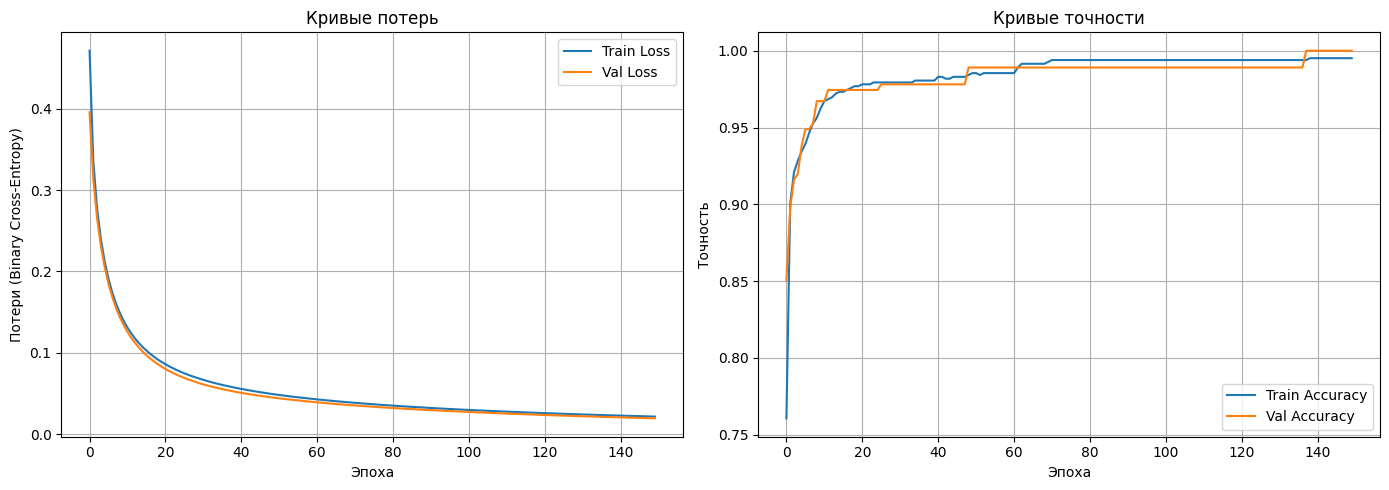

In [20]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Потери
axes[0].plot(final_model.train_loss_history, label='Train Loss')
axes[0].plot(final_model.val_loss_history, label='Val Loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери (Binary Cross-Entropy)')
axes[0].set_title('Кривые потерь')
axes[0].legend()
axes[0].grid(True)

# Точность
axes[1].plot(final_model.train_acc_history, label='Train Accuracy')
axes[1].plot(final_model.val_acc_history, label='Val Accuracy')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].set_title('Кривые точности')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Матрица ошибок

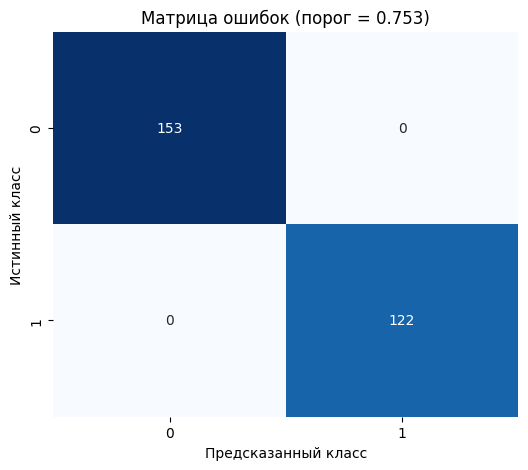

TP: 122, TN: 153, FP: 0, FN: 0


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Матрица ошибок при оптимальном пороге
cm = confusion_matrix(y_test, y_test_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок (порог = {optimal_threshold:.3f})')
plt.show()

print(f"TP: {cm[1, 1]}, TN: {cm[0, 0]}, FP: {cm[0, 1]}, FN: {cm[1, 0]}")